<a href="https://colab.research.google.com/github/2903-adi/23BIT202_CV_Lab_2026-H10-/blob/main/Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread("images (3).jpg", cv2.IMREAD_GRAYSCALE)

In [3]:
mean = 0
sigma = 75

In [6]:
noise = np.random.normal(mean, sigma, image.shape)
img1 = image.astype(np.float32) + noise
img1 = np.clip(img1, 0, 255).astype(np.uint8)

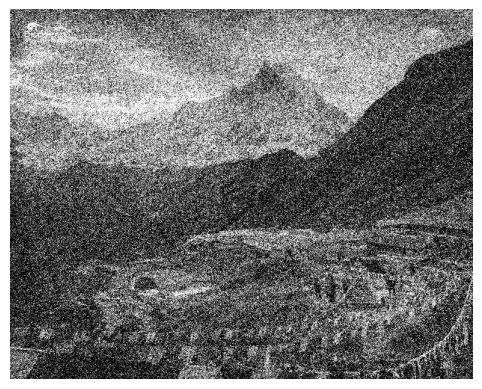

In [7]:
plt.imshow(img1,cmap="gray")
plt.axis("off")
plt.show()

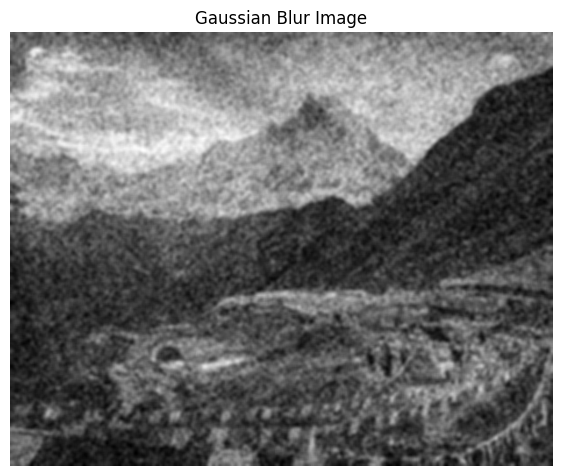

In [16]:
blur_img = cv2.GaussianBlur(img1,(7,7),2)
plt.figure(figsize=(7, 7))
plt.imshow(blur_img, cmap='gray')
plt.title("Gaussian Blur Image")
plt.axis('off')
plt.show()

In [10]:
print(image.shape)
print(img1.shape)

(495, 619)
(495, 619)


In [11]:
def gaussian_filter(img, size=7, sigma=2):
    half = size // 2
    row, col = np.mgrid[-half:half + 1, -half:half + 1]
    gauss_kernel = (1 / (2 * np.pi * sigma ** 2)) * np.exp(-(row ** 2 + col ** 2) / (2 * sigma ** 2))
    gauss_kernel = gauss_kernel /gauss_kernel.sum()
    padded_img = np.pad(img,((half, half), (half, half)), mode='edge')
    height, width = img.shape
    result = np.zeros((height, width), dtype=np.float32)
    for r in range(height):
        for c in range(width):
            window = padded_img[r:r + size, c:c + size]
            result[r, c] = np.sum(window * gauss_kernel)
    return np.clip(result, 0, 255).astype(np.uint8)

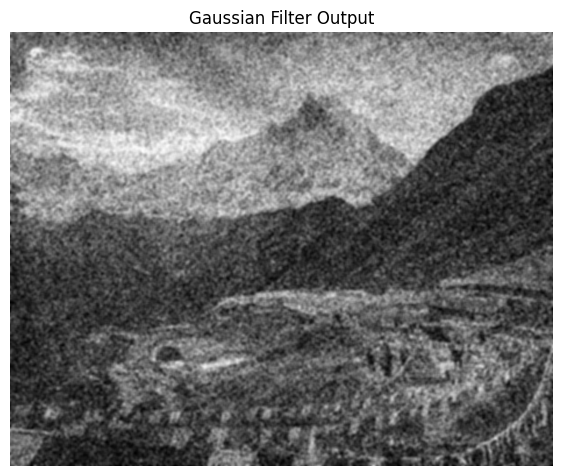

In [17]:
filtered_img = gaussian_filter(
    img1,
    size=5,
    sigma=1.5
)
plt.figure(figsize=(7, 7))
plt.imshow(filtered_img, cmap="gray")
plt.title("Gaussian Filter Output")
plt.axis("off")
plt.show()

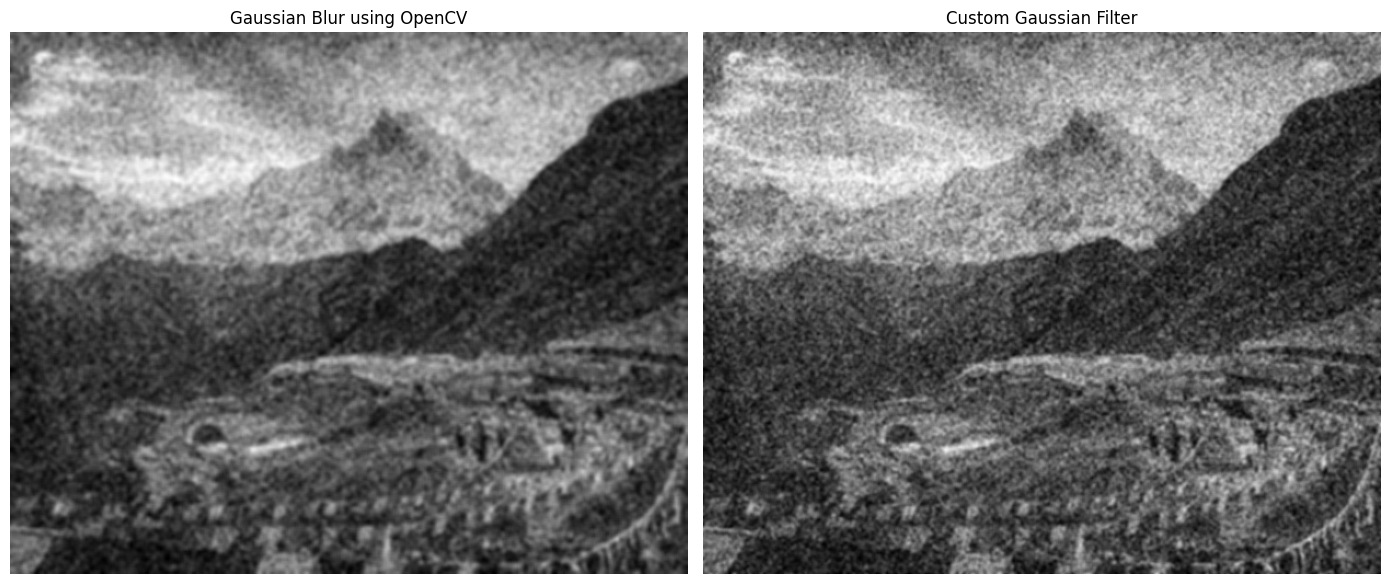

In [18]:
plt.figure(figsize=(14, 6))
plt.subplot(1,2,1)
plt.imshow(blur_img, cmap="gray")
plt.title("Gaussian Blur using OpenCV")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(filtered_img, cmap="gray")
plt.title("Custom Gaussian Filter")
plt.axis("off")
plt.tight_layout()
plt.show()